# Event-Based Framing Analysis

Analyzing how frame usage changes around major events (2015-2021).

In [1]:
%pip install pandas numpy matplotlib seaborn pyarrow scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_parquet('../data/merged_topic_and_frames_filtered.parquet')
df['date'] = pd.to_datetime(df['date'])
df['quarter'] = df['date'].dt.to_period('Q')
print(f'Loaded {len(df):,} articles')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')

frames = sorted(['economic', 'fairness', 'public_op', 'political', 'quality_life',
                 'crime', 'culture', 'health', 'legality', 'morality',
                 'policy', 'regulation', 'security', 'cap&res'])

frame_matrix = np.array(df['vector'].tolist())
for i, frame in enumerate(frames):
    df[f'frame_{frame}'] = frame_matrix[:, i]

frame_cols = [f'frame_{f}' for f in frames]

valence_map = {'Left': 'Left', 'Lean Left': 'Left', 'Center': 'Center', 'Lean Right': 'Right', 'Right': 'Right'}
df['valence'] = df['bias'].map(valence_map)

Loaded 80,783 articles
Date range: 2015-01-01 to 2021-12-31


In [4]:
events = [
    {'name': '2016 Election', 'quarter': '2016Q4'},
    {'name': 'Charlottesville', 'quarter': '2017Q3'},
    {'name': 'Parkland Shooting', 'quarter': '2018Q1'},
    {'name': 'COVID-19 Start', 'quarter': '2020Q1'},
    {'name': 'George Floyd', 'quarter': '2020Q2'},
    {'name': '2020 Election', 'quarter': '2020Q4'},
    {'name': 'Jan 6 Riot', 'quarter': '2021Q1'},
]

event_quarters = {e['quarter']: e['name'] for e in events}
print('Events:', list(event_quarters.values()))

Events: ['2016 Election', 'Charlottesville', 'Parkland Shooting', 'COVID-19 Start', 'George Floyd', '2020 Election', 'Jan 6 Riot']


## Global Frame Usage Over Time with Events

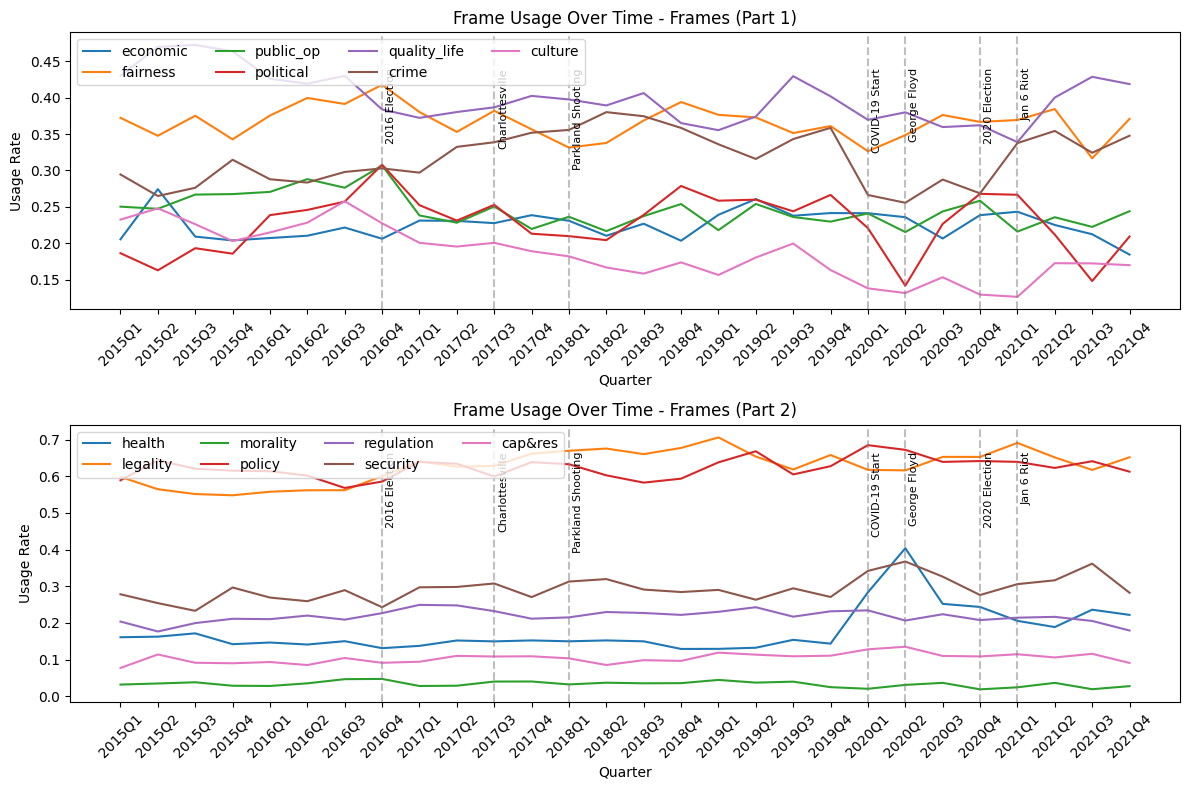

In [5]:
quarterly_global = df.groupby('quarter')[frame_cols].mean()
quarterly_global.columns = frames
quarters_list = quarterly_global.index.astype(str).tolist()

# split into two charts for readability
frames_group1 = ['economic', 'fairness', 'public_op', 'political', 'quality_life', 'crime', 'culture']
frames_group2 = ['health', 'legality', 'morality', 'policy', 'regulation', 'security', 'cap&res']

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for ax, frame_group, title in zip(axes, [frames_group1, frames_group2], ['Frames (Part 1)', 'Frames (Part 2)']):
    for frame in frame_group:
        ax.plot(quarters_list, quarterly_global[frame], label=frame, linewidth=1.5)
    
    for q, name in event_quarters.items():
        if q in quarters_list:
            idx = quarters_list.index(q)
            ax.axvline(x=idx, color='gray', linestyle='--', alpha=0.5)
            ax.text(idx + 0.1, ax.get_ylim()[1] * 0.9, name, rotation=90, va='top', fontsize=8)
    
    ax.set_title(f'Frame Usage Over Time - {title}')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Usage Rate')
    ax.legend(loc='upper left', ncol=4)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Frame Changes Around Each Event

In [6]:
def frame_change_around_event(event_q, n_before=2):
    quarters_list = sorted(df['quarter'].unique())
    event_idx = quarters_list.index(pd.Period(event_q))
    
    if event_idx < n_before:
        return None
    
    before_qs = quarters_list[event_idx - n_before:event_idx]
    event_q_period = quarters_list[event_idx]
    
    before_df = df[df['quarter'].isin(before_qs)]
    event_df = df[df['quarter'] == event_q_period]
    
    before_mean = before_df[frame_cols].mean()
    event_mean = event_df[frame_cols].mean()
    
    change = event_mean - before_mean
    change.index = frames
    return change

event_changes = {}
for e in events:
    change = frame_change_around_event(e['quarter'])
    if change is not None:
        event_changes[e['name']] = change

change_df = pd.DataFrame(event_changes).T
change_df.style.format('{:+.1%}').background_gradient(cmap='PiYG', vmin=-0.1, vmax=0.1)

,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security
2016 Election,-0.3%,+1.3%,-1.4%,-0.9%,+2.2%,-1.4%,+3.8%,+0.7%,-0.1%,+5.7%,+2.4%,-4.0%,+1.2%,-3.0%
Charlottesville,+0.6%,+2.3%,+0.3%,-0.3%,+1.6%,+0.4%,-0.5%,+1.2%,-3.7%,+1.2%,+1.7%,+1.0%,-1.6%,+1.0%
Parkland Shooting,-0.5%,+1.0%,-1.2%,-0.3%,-3.6%,-0.1%,+2.2%,-0.8%,+1.1%,-2.1%,+0.3%,+0.2%,-0.5%,+2.6%
COVID-19 Start,+1.8%,-8.5%,-4.3%,+0.2%,-3.0%,+13.5%,-2.1%,-1.2%,+6.8%,-3.5%,+0.8%,-4.6%,+1.0%,+5.9%
George Floyd,+1.6%,-5.7%,-1.9%,-0.6%,+0.5%,+19.0%,-2.2%,+0.8%,+1.6%,-10.2%,-2.0%,-0.6%,-2.6%,+6.1%
2020 Election,-1.4%,-0.4%,-1.3%,+1.8%,+0.4%,-8.2%,+1.8%,-1.5%,-1.4%,+8.2%,+2.8%,-0.7%,-0.8%,-7.0%
Jan 6 Riot,+0.5%,+6.2%,-1.2%,+1.6%,-0.1%,-4.1%,+3.8%,-0.1%,-0.1%,+1.4%,-3.7%,-2.2%,+0.1%,+1.1%


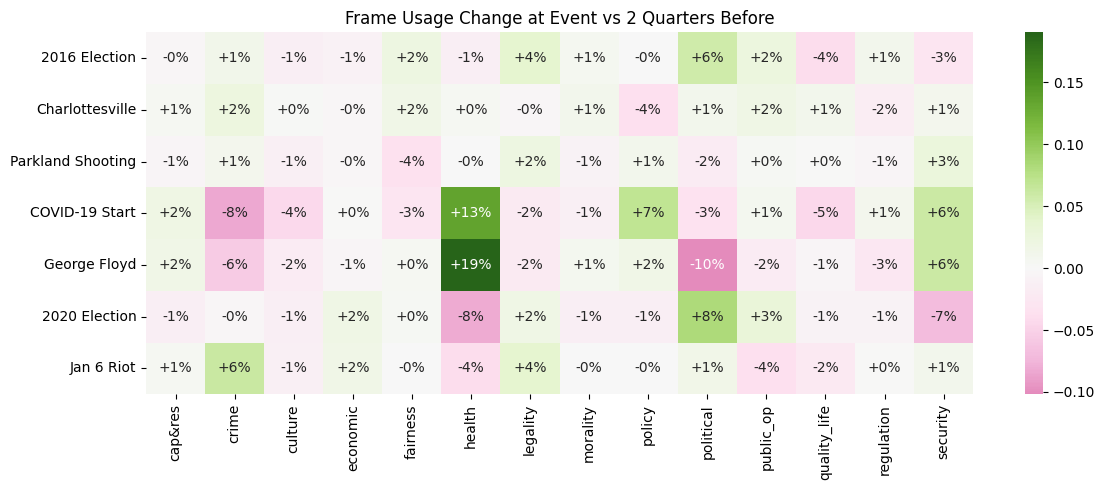

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(change_df, annot=True, fmt='+.0%', cmap='PiYG', center=0, ax=ax)
plt.title('Frame Usage Change at Event vs 2 Quarters Before')
plt.tight_layout()
plt.show()

In [8]:
print('Largest frame changes per event:\n')
for event_name, changes in event_changes.items():
    top_changes = changes.abs().sort_values(ascending=False).head(3)
    print(f'{event_name}:')
    for frame in top_changes.index:
        print(f'  {frame}: {changes[frame]:+.1%}')
    print()

Largest frame changes per event:

2016 Election:
  political: +5.7%
  quality_life: -4.0%
  legality: +3.8%

Charlottesville:
  policy: -3.7%
  crime: +2.3%
  public_op: +1.7%

Parkland Shooting:
  fairness: -3.6%
  security: +2.6%
  legality: +2.2%

COVID-19 Start:
  health: +13.5%
  crime: -8.5%
  policy: +6.8%

George Floyd:
  health: +19.0%
  political: -10.2%
  security: +6.1%

2020 Election:
  political: +8.2%
  health: -8.2%
  security: -7.0%

Jan 6 Riot:
  crime: +6.2%
  health: -4.1%
  legality: +3.8%



## Frame Changes by Political Valence Around Events

In [9]:
def frame_change_by_valence(event_q, n_before=2):
    quarters_list = sorted(df['quarter'].unique())
    event_idx = quarters_list.index(pd.Period(event_q))
    
    if event_idx < n_before:
        return None
    
    before_qs = quarters_list[event_idx - n_before:event_idx]
    event_q_period = quarters_list[event_idx]
    
    results = {}
    for valence in ['Left', 'Center', 'Right']:
        v_df = df[df['valence'] == valence]
        before_mean = v_df[v_df['quarter'].isin(before_qs)][frame_cols].mean()
        event_mean = v_df[v_df['quarter'] == event_q_period][frame_cols].mean()
        change = event_mean - before_mean
        change.index = frames
        results[valence] = change
    
    return pd.DataFrame(results)

key_events = ['George Floyd', 'COVID-19 Start', '2016 Election', 'Jan 6 Riot']
for event in events:
    if event['name'] in key_events:
        valence_change = frame_change_by_valence(event['quarter'])
        if valence_change is not None:
            print(f"\n=== {event['name']} ===")
            display(valence_change.style.format('{:+.1%}').background_gradient(cmap='PiYG', vmin=-0.1, vmax=0.1, axis=None))


=== 2016 Election ===


,Left,Center,Right
cap&res,-2.9%,+8.7%,-0.4%
crime,+2.9%,-0.6%,-2.4%
culture,+0.2%,+0.7%,-3.1%
economic,-4.4%,+9.2%,-0.5%
fairness,+3.5%,+6.6%,-2.6%
health,-0.1%,-3.6%,-1.1%
legality,+4.3%,+4.1%,-0.1%
morality,+1.5%,+0.3%,-0.8%
policy,+0.1%,-0.1%,-0.2%
political,+5.3%,+9.6%,+2.8%



=== COVID-19 Start ===


,Left,Center,Right
cap&res,-0.3%,+5.8%,+0.4%
crime,-9.4%,-7.1%,-8.6%
culture,-3.1%,-5.7%,-3.8%
economic,-1.9%,+2.6%,-0.6%
fairness,-1.6%,-5.3%,-2.3%
health,+13.4%,+21.8%,+8.3%
legality,-4.2%,+0.2%,-2.3%
morality,-0.7%,-0.3%,-2.2%
policy,+8.4%,+4.2%,+7.0%
political,-3.4%,-5.3%,-2.2%



=== George Floyd ===


,Left,Center,Right
cap&res,+2.0%,-1.6%,+1.4%
crime,-4.8%,-3.1%,-5.9%
culture,-2.7%,-2.8%,-0.6%
economic,+1.1%,-7.4%,-0.2%
fairness,+1.9%,+3.5%,-0.6%
health,+18.4%,+16.9%,+20.2%
legality,+0.1%,+1.0%,-4.1%
morality,+1.4%,-0.1%,+1.3%
policy,+1.1%,-2.0%,+2.0%
political,-11.4%,-3.1%,-12.2%



=== Jan 6 Riot ===


,Left,Center,Right
cap&res,+0.6%,-0.4%,-0.1%
crime,+11.8%,+3.0%,+5.2%
culture,-2.0%,+1.4%,-1.8%
economic,+1.7%,+0.3%,+0.4%
fairness,+0.8%,-0.8%,+0.9%
health,-8.4%,-3.1%,-1.5%
legality,+8.4%,-2.3%,+5.1%
morality,+0.5%,-0.2%,-0.3%
policy,-1.1%,-2.0%,+0.4%
political,+3.2%,+1.0%,+1.3%


In [10]:
print('Left/Right framing divergence at events:')
print('(positive = Left increased more than Right)\n')

divergence_data = []
for event in events:
    valence_change = frame_change_by_valence(event['quarter'])
    if valence_change is not None:
        left_right_diff = valence_change['Left'] - valence_change['Right']
        top_divergence = left_right_diff.abs().sort_values(ascending=False).head(3)
        print(f"{event['name']}:")
        for frame in top_divergence.index:
            print(f'  {frame}: {left_right_diff[frame]:+.1%}')
        print()
        
        divergence_data.append({'event': event['name'], 'avg_divergence': left_right_diff.abs().mean()})

div_df = pd.DataFrame(divergence_data).sort_values('avg_divergence', ascending=False)
print('\nAverage Left/Right divergence by event:')
for _, row in div_df.iterrows():
    print(f"  {row['event']}: {row['avg_divergence']:.1%}")

Left-Right framing divergence at events:
(positive = Left increased more than Right)

2016 Election:
  quality_life: -7.1%
  fairness: +6.1%
  crime: +5.3%

Charlottesville:
  regulation: -4.1%
  public_op: +3.8%
  fairness: -3.1%

Parkland Shooting:
  culture: -7.9%
  economic: -7.4%
  quality_life: -4.9%

COVID-19 Start:
  health: +5.1%
  public_op: +4.2%
  regulation: -2.9%

George Floyd:
  security: -4.7%
  legality: +4.2%
  fairness: +2.5%



2020 Election:
  political: +15.3%
  fairness: +8.5%
  public_op: +7.3%

Jan 6 Riot:
  health: -6.9%
  crime: +6.6%
  security: +5.8%


Average Left-Right divergence by event:
  2020 Election: 4.5%
  Parkland Shooting: 3.6%
  2016 Election: 3.1%
  Jan 6 Riot: 2.3%
  COVID-19 Start: 1.7%
  George Floyd: 1.6%
  Charlottesville: 1.6%


## Topic-Specific Event Analysis

In [2]:
event_topic_pairs = [
    ('George Floyd', 'crime'),
    ('COVID-19 Start', 'healthcare'),
    ('COVID-19 Start', 'pandemic'),
    ('2016 Election', 'elections and politics'),
    ('2020 Election', 'elections and politics'),
    ('Jan 6 Riot', 'elections and politics'),
]

def frame_change_for_topic(event_q, topic, n_before=2):
    quarters_list = sorted(df['quarter'].unique())
    event_idx = quarters_list.index(pd.Period(event_q))
    
    if event_idx < n_before:
        return None
    
    before_qs = quarters_list[event_idx - n_before:event_idx]
    event_q_period = quarters_list[event_idx]
    
    topic_df = df[df['topic_top1'] == topic]
    before_mean = topic_df[topic_df['quarter'].isin(before_qs)][frame_cols].mean()
    event_mean = topic_df[topic_df['quarter'] == event_q_period][frame_cols].mean()
    
    change = event_mean - before_mean
    change.index = frames
    return change

print('Frame changes for topic/event pairs:\n')
for event_name, topic in event_topic_pairs:
    event_q = next(e['quarter'] for e in events if e['name'] == event_name)
    change = frame_change_for_topic(event_q, topic)
    if change is not None:
        top_changes = change.abs().sort_values(ascending=False).head(3)
        print(f'{event_name} + {topic}:')
        for frame in top_changes.index:
            print(f'  {frame}: {change[frame]:+.1%}')
        print()

Frame changes for topic/event pairs:



NameError: name 'events' is not defined